# 00. 문제 정의 및 데이터 설명

**대회**: 데이콘 x BDA 제2회 학습자 수료 예측 AI 경진대회

**목표**: 9기 학습자 데이터를 활용하여 10기 학습자의 수료 여부 예측

## 1. 라이브러리 Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import warnings

warnings.filterwarnings(action='ignore')
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')

system = platform.system()
if system == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif system == 'Darwin':
	plt.rcParams['font.family'] = 'AppleGothic'
plt.rc('axes', unicode_minus=False)

## 2. 데이터 로드

In [2]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (748, 46)
Test shape: (814, 45)


In [3]:
# 첫 5행 확인
train.head()

,ID,generation,school1,major type,major1_1,major1_2,major_data,job,class1,class2,...,incumbents_company_level,incumbents_lecture_type,incumbents_lecture_scale,incumbents_lecture_scale_reason,interested_company,expected_domain,contest_participation,idea_contest,onedayclass_topic,completed
0,TRAIN_000,9,22,"복수 전공 ( 다중전공, 이중전공 포함 )",경제통상학,자연과학,False,대학생,1,4.0,...,해외 기업 (빅테크),"온, 오프라인 동시",100명 이상의 리스너와 10명 이상의 현직자,다양한 사람들과 만나서 생각을 교류할 수 있기 때문,"구글 딥마인드, 카카오 브레인","M. 전문, 과학 및 기술 서비스업",NaN,NaN,"Python 응용, 데이터 시각화 (Matplotlib, Seaborn 등), 머신...",0
1,TRAIN_001,9,1,"복수 전공 ( 다중전공, 이중전공 포함 )",자연과학,IT(컴퓨터 공학 포함),True,대학생,8,NaN,...,국내 빅테크 IT 계열 (네카라쿠배당토),오프라인,3~50명 내외의 강의 리스너와 1명의 현직자,더 많은 사람들이 있으면 제가 예상하지 못한 질문도 할 수 있다고 생각하기 때문입니다.,제일 기획,"J. 정보통신업, O. 공공 행정, 국방 및 사회보장 행정",NaN,NaN,머신러닝 / 딥러닝 응용,0
2,TRAIN_002,9,27,단일 전공,예체능,NaN,False,대학생,7,NaN,...,"국내 대기업 IT 계열 (금융, 제조 ...)",오프라인,3~50명 내외의 강의 리스너와 1명의 현직자,인원이 너무 적으면 서로 부담스러울 수 있을 것 같지만 너무 많으면 너무 피상적인 ...,Lg전자,"C. 제조업, K. 금융 및 보험업, R. 예술, 스포츠 및 여가관련 서비스업",NaN,NaN,"머신러닝 / 딥러닝 응용, SQL 응용, 웹 크롤링",0
3,TRAIN_003,9,1,"복수 전공 ( 다중전공, 이중전공 포함 )",사회과학,IT(컴퓨터 공학 포함),False,대학생,7,NaN,...,국내 빅테크 IT 계열 (네카라쿠배당토),"온, 오프라인 동시",3~50명 내외의 강의 리스너와 1명의 현직자,너무 많은 인원이 강의하면 루즈해질 것 같아서,네이버,"J. 정보통신업, K. 금융 및 보험업",NaN,NaN,머신러닝 / 딥러닝 응용,1
4,TRAIN_004,9,16,"복수 전공 ( 다중전공, 이중전공 포함 )",IT(컴퓨터 공학 포함),IT(컴퓨터 공학 포함),True,대학생,8,NaN,...,"국내 대기업 IT 계열 (금융, 제조 ...)","온, 오프라인 동시",3~50명 내외의 강의 리스너와 1명의 현직자,다양한 사람들에게 기회가 있으면 좋겠습니다.,네이버,"K. 금융 및 보험업, M. 전문, 과학 및 기술 서비스업, R. 예술, 스포츠 및...",NaN,NaN,"머신러닝 / 딥러닝 응용, SQL 응용, 웹 크롤링",0


## 3. 변수 설명

총 **45개 변수** (Target 포함)

In [4]:
# 컬럼 정보
print(f"총 변수 개수: {len(train.columns)}")
print("\n컬럼 목록:")
for i, col in enumerate(train.columns, 1):
    print(f"{i:2d}. {col}")

총 변수 개수: 46

컬럼 목록:
 1. ID
 2. generation
 3. school1
 4. major type
 5. major1_1
 6. major1_2
 7. major_data
 8. job
 9. class1
10. class2
11. class3
12. class4
13. re_registration
14. contest_award
15. nationality
16. inflow_route
17. whyBDA
18. what_to_gain
19. hope_for_group
20. previous_class_3
21. previous_class_4
22. previous_class_5
23. previous_class_6
24. previous_class_7
25. previous_class_8
26. major_field
27. desired_career_path
28. completed_semester
29. project_type
30. time_input
31. desired_job
32. certificate_acquisition
33. desired_certificate
34. desired_job_except_data
35. incumbents_level
36. incumbents_lecture
37. incumbents_company_level
38. incumbents_lecture_type
39. incumbents_lecture_scale
40. incumbents_lecture_scale_reason
41. interested_company
42. expected_domain
43. contest_participation
44. idea_contest
45. onedayclass_topic
46. completed


### 변수 그룹별 정리

#### 1. 기본 정보
- `ID`: 샘플 ID
- `generation`: BDA 기수
- `school1`: 대학교 (익명화 숫자 코드)
- `nationality`: 내/외국인
- `completed_semester`: 대학교 이수학기

#### 2. 전공 정보
- `major_field`: 전공 분야 대분류 — L1=0.421 (주의, 일부 카테고리만 신뢰)
- `major type`: 복수전공 여부 (컬럼명에 공백 포함) — L1=0.123
- `major1_1`: 제1전공 세부 — L1=1.947, 사용 불가
- `major1_2`: 제2전공 세부 — L1=1.550, 사용 불가
- `major_data`: 제1전공 전공자 여부 (bool)

#### 3. 직업 및 희망 진로
- `job`: 현재 직무 — L1=0.075 (안정)
- `desired_job`: 희망 직무 — L1=1.285, 사용 불가
- `desired_career_path`: 희망 진로
- `desired_job_except_data`: 데이터 외 희망 직무

#### 4. 학습 관련
- `re_registration`: 재등록 여부 — L1=0.010 (매우 안정), Lift=1.38
- `time_input`: 하루 BDA 투입 시간 — 분포 안정
- `class1~4`: 수강 분반 (class3, class4는 거의 결측)
- `previous_class_3~8`: 과거 기수 수강 분반 (~80% 결측)
- `project_type`: 팀/개인 프로젝트 희망

#### 5. 자유 텍스트 / 설문
- `whyBDA`: BDA 선택 이유 — L1=0.413 (주의, "혼자 공부하기 어려워서" 패턴 공통)
- `what_to_gain`: 얻고싶은 것 — L1=0.097 (안정)
- `incumbents_lecture_scale_reason`: 강의 규모 선택 이유 — L1=1.788, 불안정
- `interested_company`: 관심 기업명 — L1=1.177, 사용 불가
- `incumbents_level`, `incumbents_lecture`, `incumbents_company_level`, `incumbents_lecture_type`, `incumbents_lecture_scale`: 현직자 강연 관련
- `certificate_acquisition`, `desired_certificate`: 자격증 관련
- `contest_participation`: 데이터 대회 경험 — 99.2% 결측
- `onedayclass_topic`: 원데이 클래스 주제 — L1=1.912, 사용 불가
- `expected_domain`: 희망 도메인

#### 6. 전체 결측 컬럼 (사용 불가)
- `contest_award`: 748개 전체 결측
- `idea_contest`: 748개 전체 결측

#### 7. Target
- `completed`: 수료 여부 (0: 미수료, 1: 수료)

## 4. Target 분포

In [5]:
# Target 분포
target_dist = train['completed'].value_counts().sort_index()
print("Target 분포:")
print(target_dist)
print(f"\n수료율: {train['completed'].mean():.2%}")

Target 분포:
completed
0    525
1    223
Name: count, dtype: int64

수료율: 29.81%


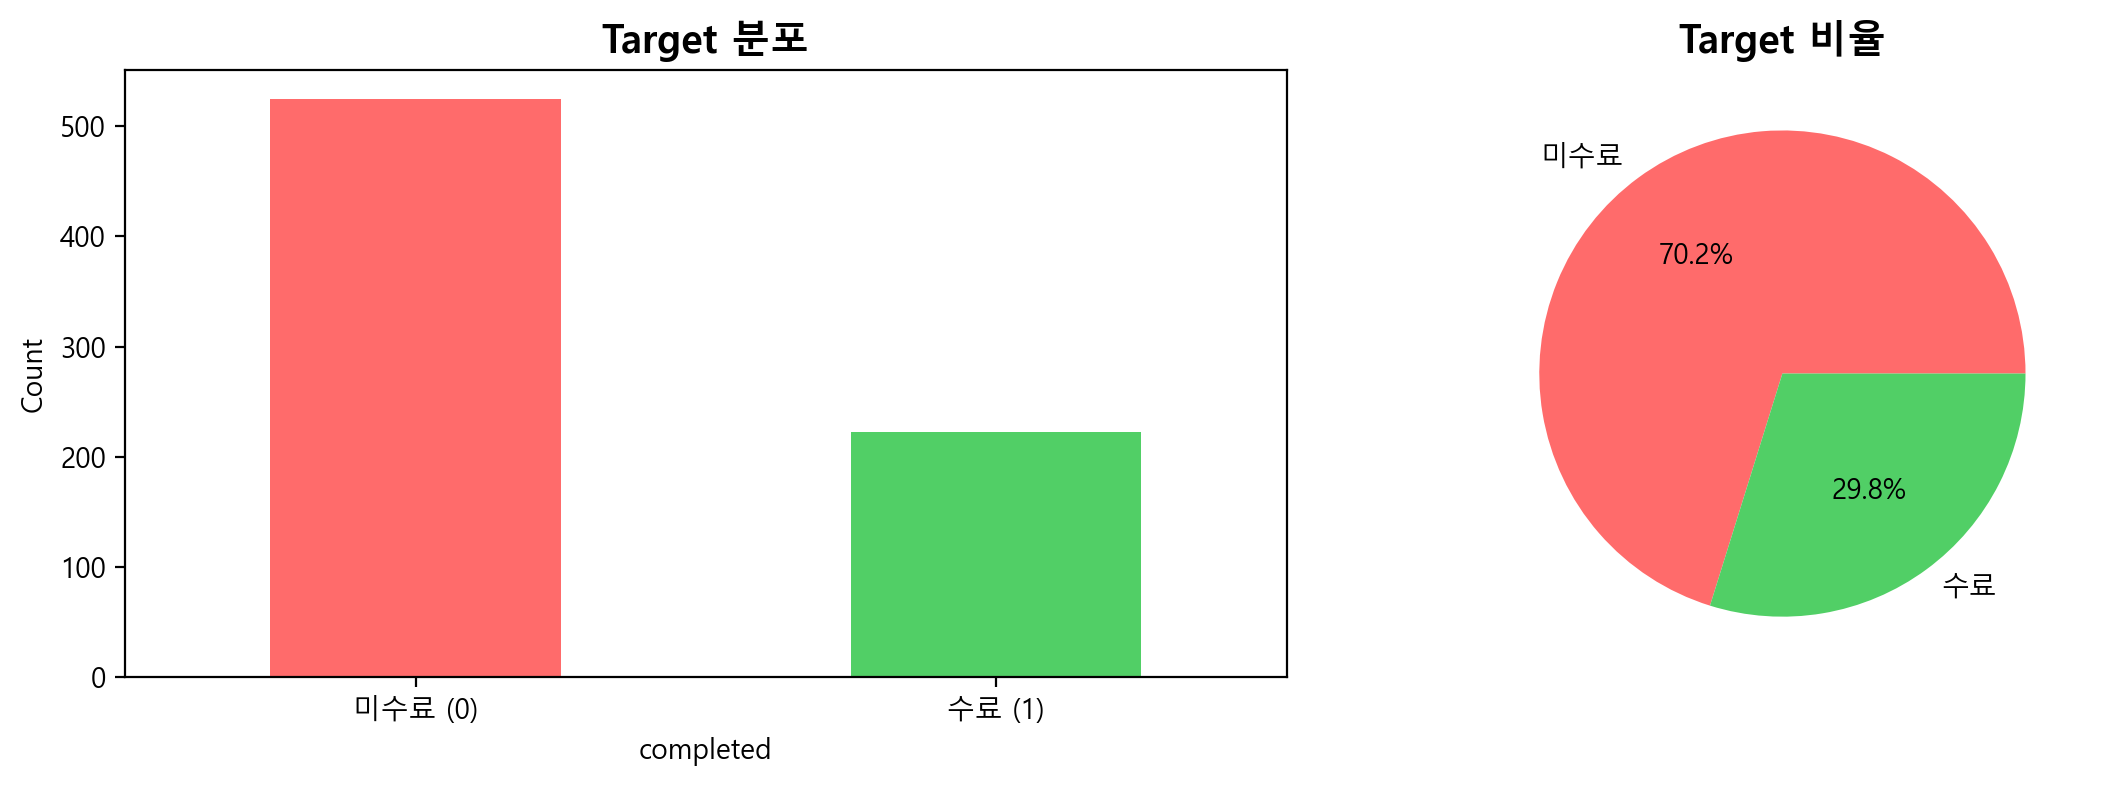

In [6]:
# 시각화
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 막대 그래프
target_dist.plot(kind='bar', ax=ax[0], color=['#ff6b6b', '#51cf66'])
ax[0].set_title('Target 분포', fontsize=14, fontweight='bold')
ax[0].set_xlabel('completed')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(['미수료 (0)', '수료 (1)'], rotation=0)

# 파이 차트
target_dist.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', 
                 colors=['#ff6b6b', '#51cf66'], labels=['미수료', '수료'])
ax[1].set_title('Target 비율', fontsize=14, fontweight='bold')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 5. 기본 통계

In [7]:
# 데이터 타입
print("=" * 60)
print("데이터 타입별 변수 개수")
print("=" * 60)
print(train.dtypes.value_counts())

print("\n" + "=" * 60)
print("범주형 변수 (object)")
print("=" * 60)
cat_cols = train.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"- {col}")

데이터 타입별 변수 개수
object     34
float64     7
int64       4
bool        1
Name: count, dtype: int64

범주형 변수 (object)
- ID
- major type
- major1_1
- major1_2
- job
- re_registration
- nationality
- inflow_route
- whyBDA
- what_to_gain
- hope_for_group
- previous_class_3
- previous_class_4
- previous_class_5
- previous_class_6
- previous_class_7
- previous_class_8
- major_field
- desired_career_path
- project_type
- desired_job
- certificate_acquisition
- desired_certificate
- desired_job_except_data
- incumbents_level
- incumbents_lecture
- incumbents_company_level
- incumbents_lecture_type
- incumbents_lecture_scale
- incumbents_lecture_scale_reason
- interested_company
- expected_domain
- contest_participation
- onedayclass_topic


In [8]:
# 결측치
missing = train.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing': missing,
    'Percent': missing_pct
})

print("결측치 상위 10개:")
print(missing_df[missing_df['Missing'] > 0].head(10))

결측치 상위 10개:
                       Missing  Percent
contest_award              748   100.00
idea_contest               748   100.00
class4                     747    99.87
contest_participation      742    99.20
class3                     734    98.13
previous_class_5           602    80.48
previous_class_3           602    80.48
previous_class_6           602    80.48
previous_class_8           602    80.48
previous_class_7           602    80.48


## 6. 핵심 변수 분포

통계적으로 유의미한 변수들을 먼저 확인

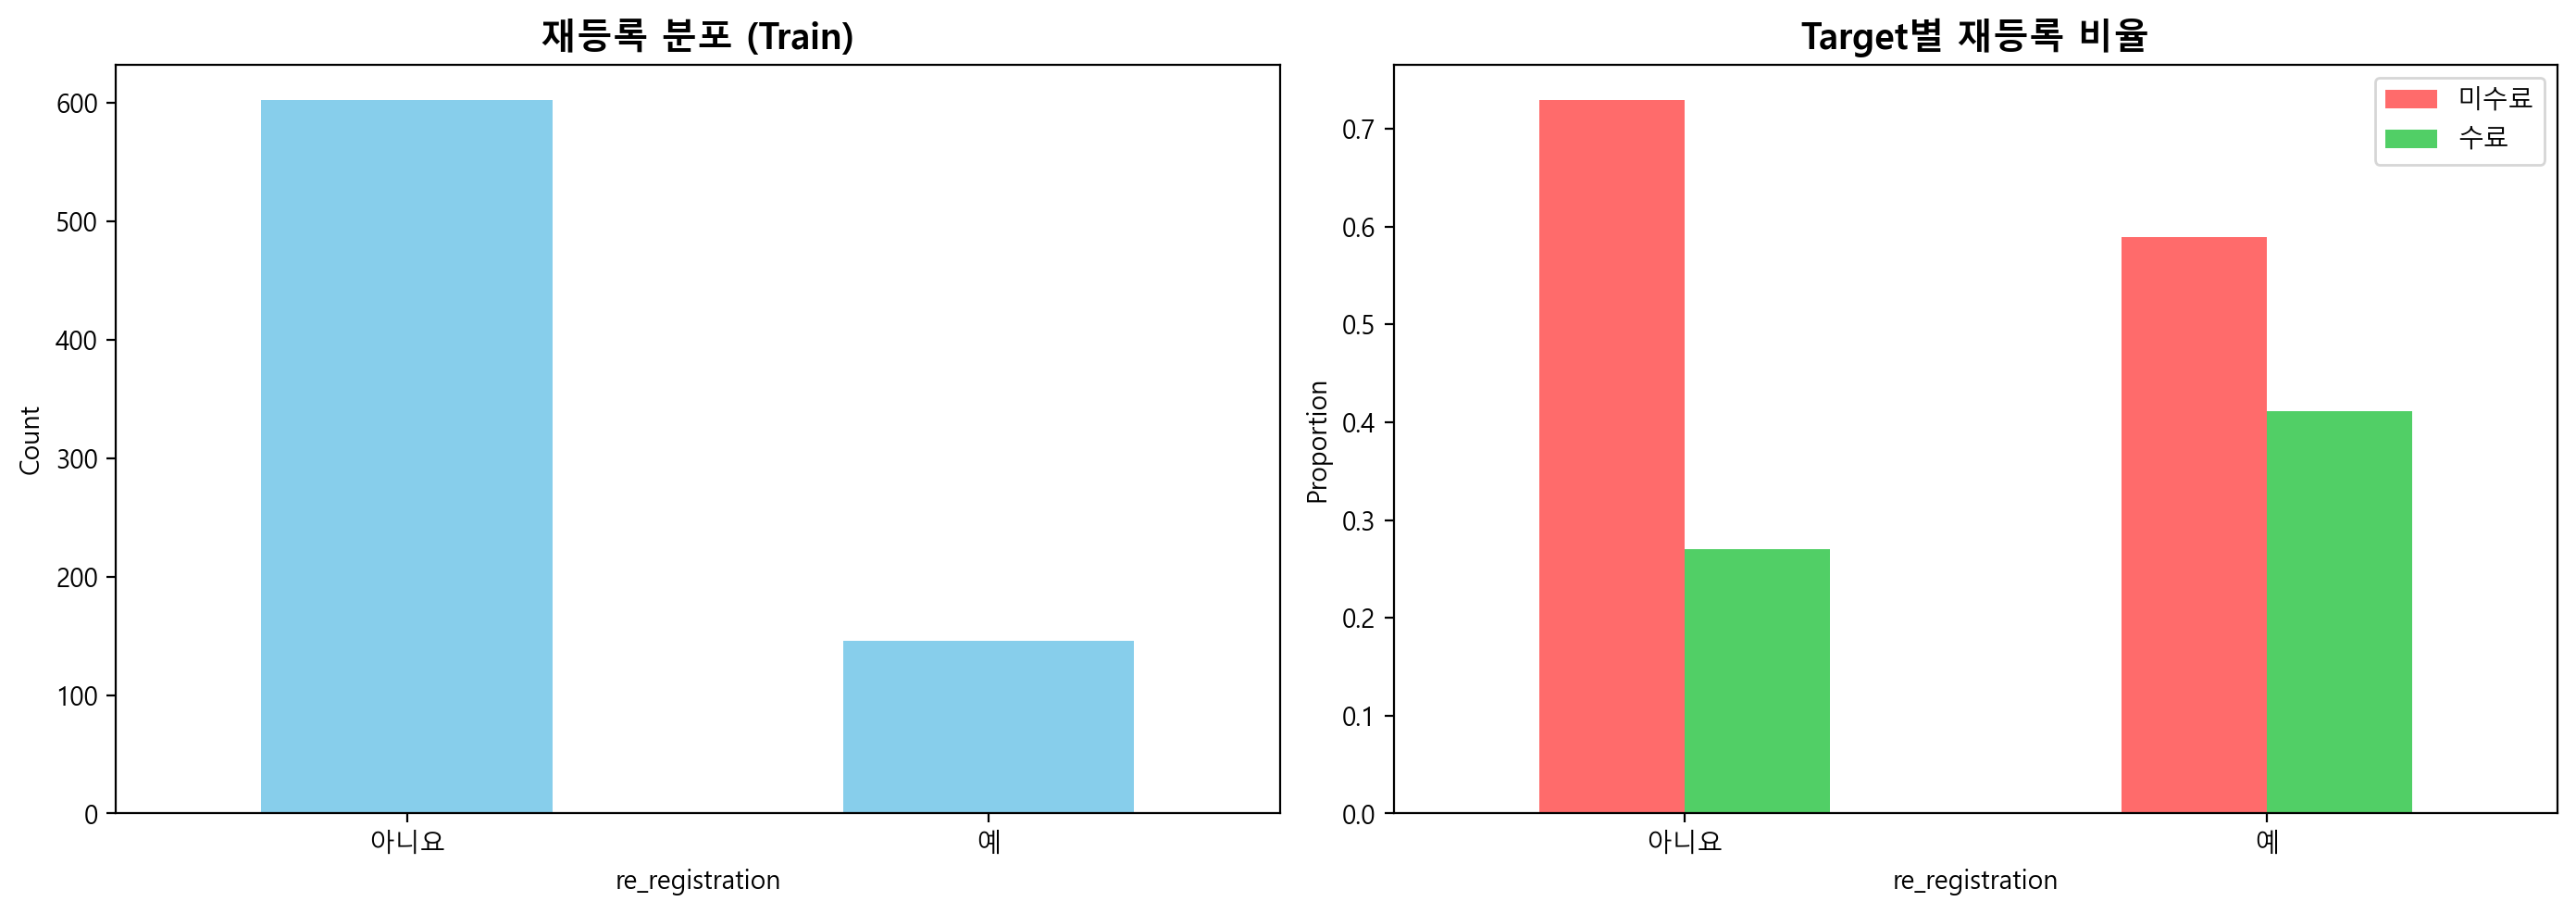

In [9]:
# 재등록
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Train 분포
train['re_registration'].value_counts().plot(kind='bar', ax=ax[0], color='skyblue')
ax[0].set_title('재등록 분포 (Train)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('re_registration')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)

# Target별 재등록 분포
pd.crosstab(train['re_registration'], train['completed'], normalize='index').plot(
    kind='bar', ax=ax[1], color=['#ff6b6b', '#51cf66']
)
ax[1].set_title('Target별 재등록 비율', fontsize=14, fontweight='bold')
ax[1].set_xlabel('re_registration')
ax[1].set_ylabel('Proportion')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)
ax[1].legend(['미수료', '수료'])

plt.tight_layout()
plt.show()

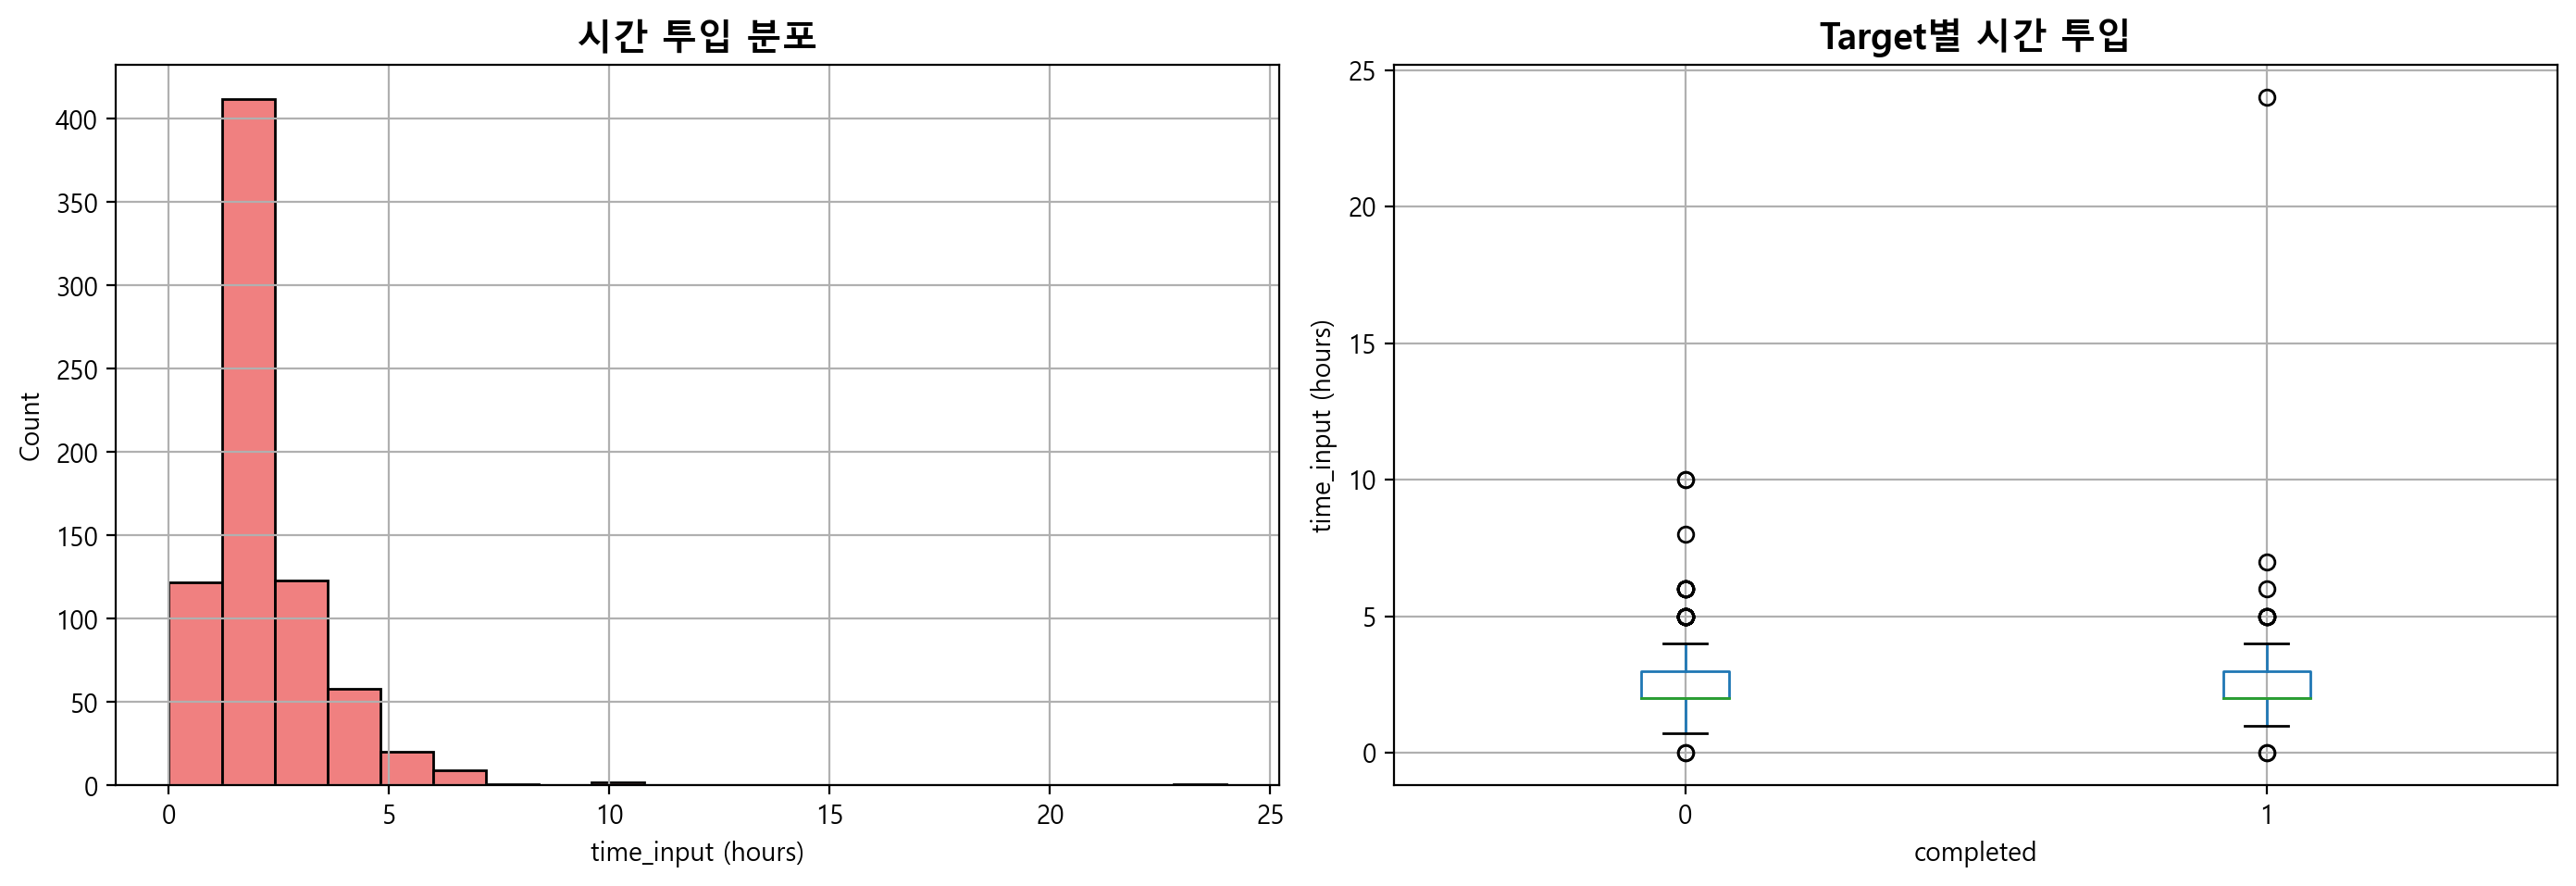

Target별 시간 투입 평균:
completed
0    2.303238
1    2.381166
Name: time_input, dtype: float64


In [10]:
# 시간 투입
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 분포
train['time_input'].hist(bins=20, ax=ax[0], color='lightcoral', edgecolor='black')
ax[0].set_title('시간 투입 분포', fontsize=14, fontweight='bold')
ax[0].set_xlabel('time_input (hours)')
ax[0].set_ylabel('Count')

# Target별 분포
train.boxplot(column='time_input', by='completed', ax=ax[1])
ax[1].set_title('Target별 시간 투입', fontsize=14, fontweight='bold')
ax[1].set_xlabel('completed')
ax[1].set_ylabel('time_input (hours)')
plt.suptitle('')

plt.tight_layout()
plt.show()

# 통계
print("Target별 시간 투입 평균:")
print(train.groupby('completed')['time_input'].mean())

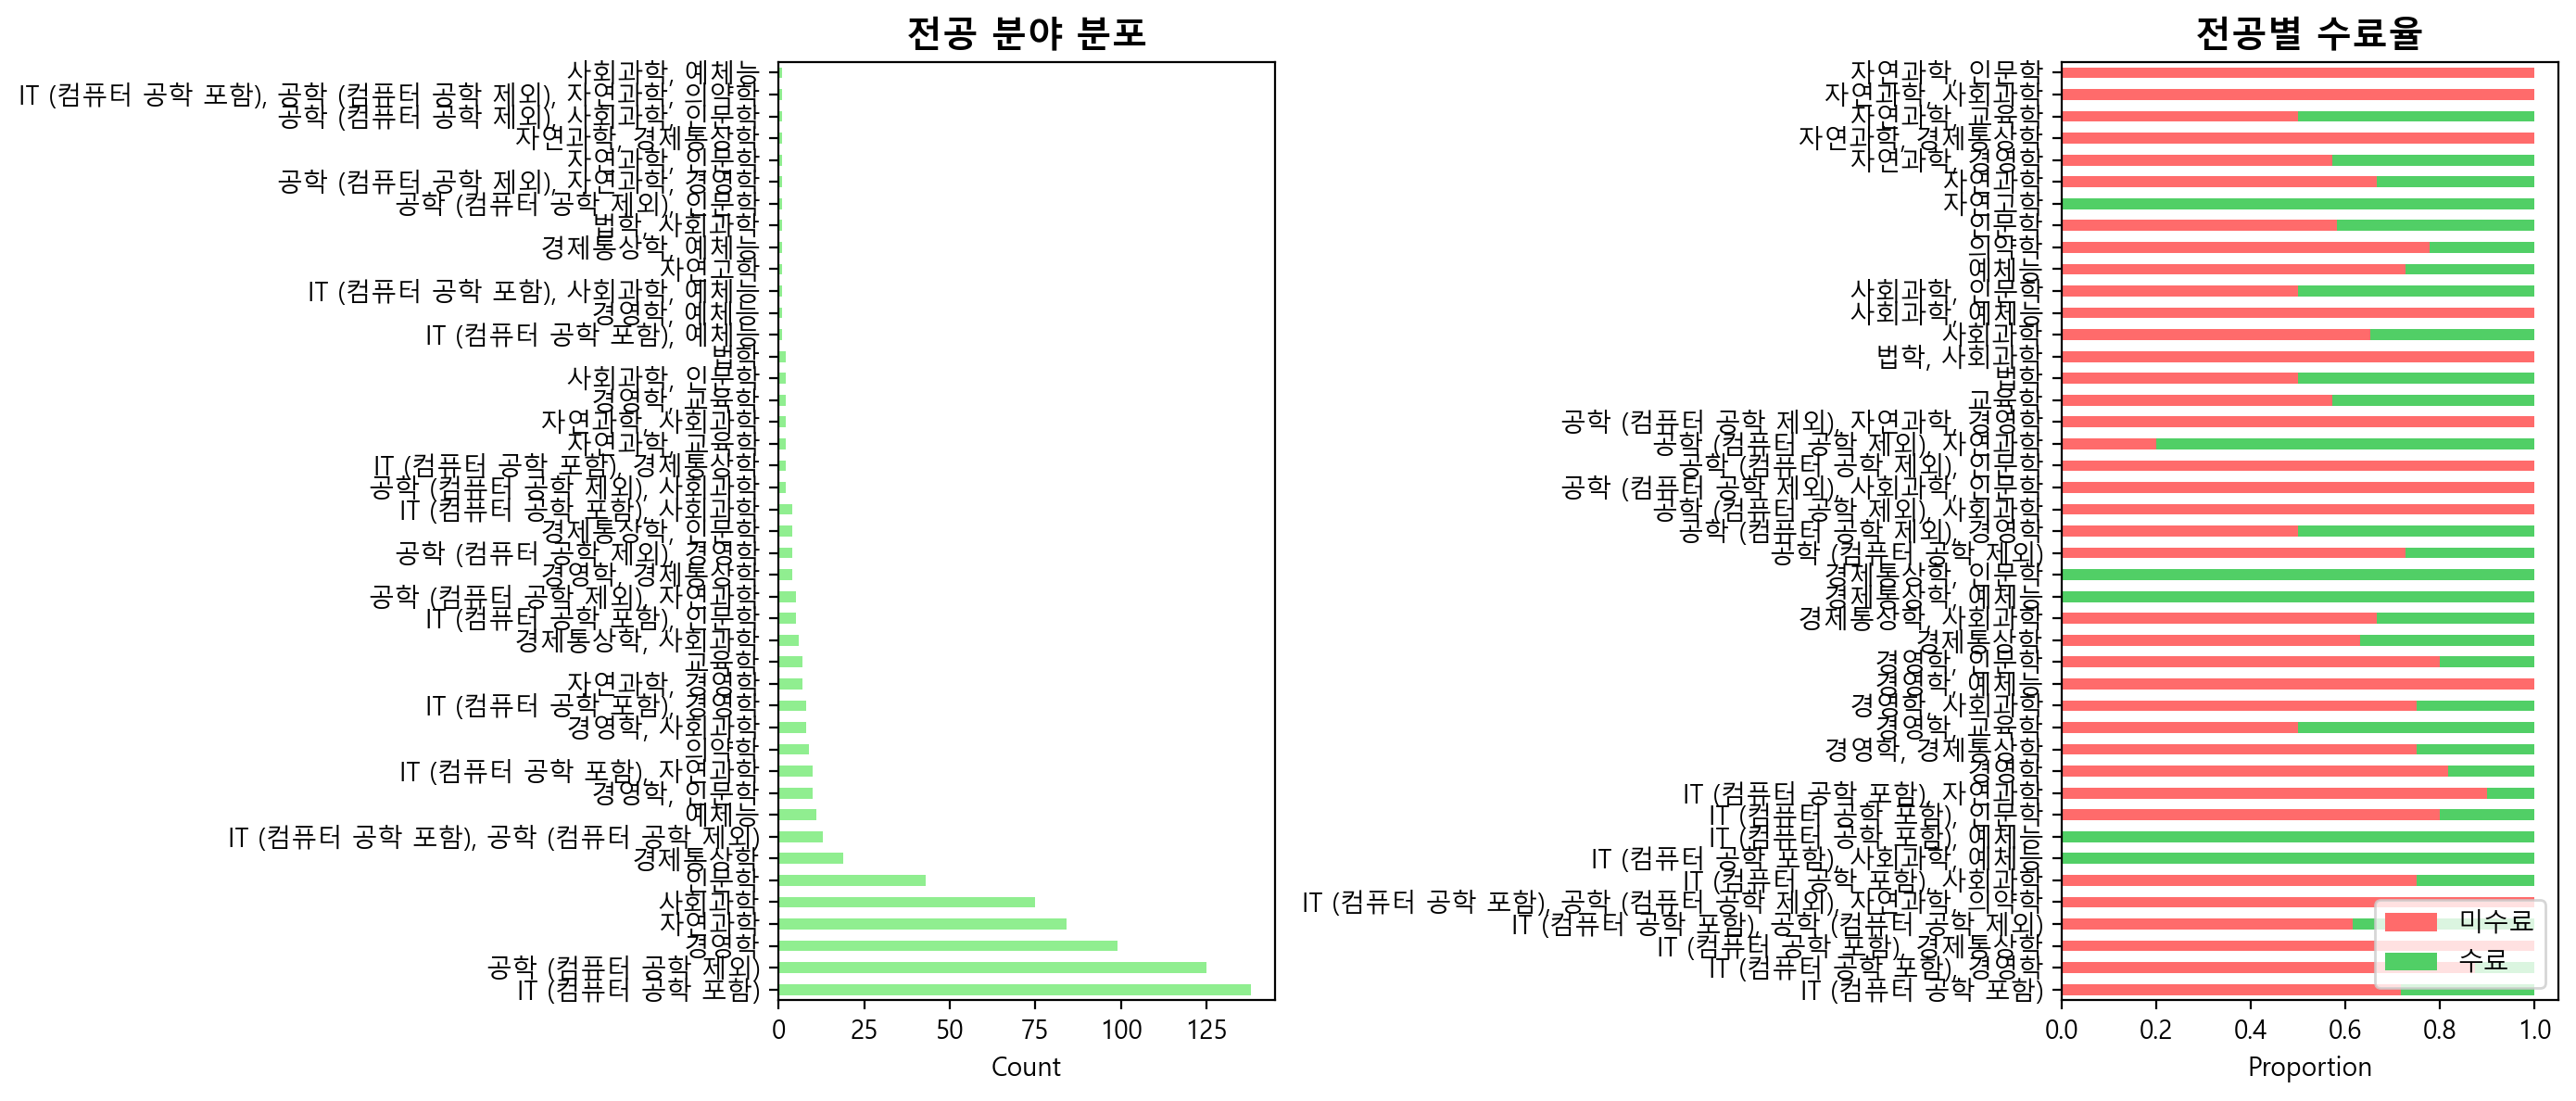

In [11]:
# 전공 분야
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Train 분포
train['major_field'].value_counts().plot(kind='barh', ax=ax[0], color='lightgreen')
ax[0].set_title('전공 분야 분포', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Count')
ax[0].set_ylabel('')

# Target별
pd.crosstab(train['major_field'], train['completed'], normalize='index').plot(
    kind='barh', ax=ax[1], color=['#ff6b6b', '#51cf66'], stacked=True
)
ax[1].set_title('전공별 수료율', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Proportion')
ax[1].set_ylabel('')
ax[1].legend(['미수료', '수료'], loc='lower right')

plt.tight_layout()
plt.show()

## 7. 요약

### 데이터 특성
- Train: 748명 (9기)
- Test: **814명** (10기)
- Target: 불균형 — 미수료 525명 (70.2%), 수료 223명 (29.8%)
- 변수: 46개 (ID + Target 포함)

### 사용 불가 변수
- `contest_award`, `idea_contest`: 100% 결측
- `major1_1`, `major1_2`, `onedayclass_topic`, `incumbents_lecture_scale_reason`: L1 > 1.5 (Train/Test 분포 완전 다름)

### 핵심 신호 (안정 변수 기준)
1. **재등록** (L1=0.010): 재등록자의 수료율이 높음 (Lift=1.38)
2. **시간 투입** (time_input): 분포 안정, 수료율과 양의 관계
3. **전공 분야 일부**: 자연과학, 인문학, 법학 카테고리별 수료율 차이

### 핵심 문제
- CV OOF F1: ~0.49 vs Public LB: 0.37 — Gap -0.12
- Train(9기)과 Test(10기)의 분포가 달라 일반적 ML 과적합 위험 높음
- 해결책: L1 Distance 기반 안정 변수 선별 + Flip-rate (Top-k 선발)

### 대회 최종 결과
- Public F1: **0.44897** — 43위 / 733팀
- Private F1: **0.41071** — **26위 / 733팀 (상위 3.5%)**
- Public 43위 → Private 26위: +17등 상승 (안정 신호 기반 접근의 일반화 성능 검증)

### 다음 단계
- EDA (01_eda.ipynb)
- Train/Test Drift 분석 (02_train_test_drift.ipynb)
- Lift 분석 (03_lift_analysis.ipynb)